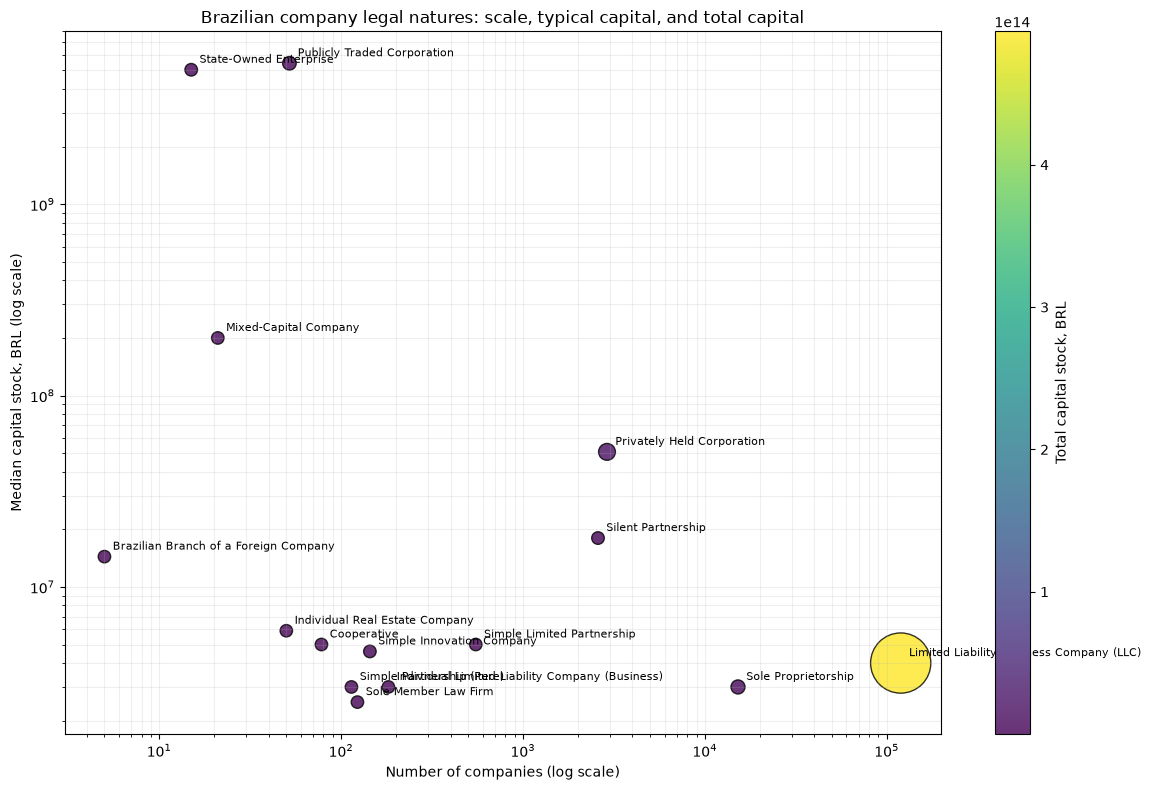

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2026/2026-01-27/companies.csv"
companies = pd.read_csv(url)

companies["capital_stock"] = pd.to_numeric(
    companies["capital_stock"].astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

summary = (
    companies.dropna(subset=["legal_nature", "capital_stock"])
    .groupby("legal_nature")
    .agg(
        companies=("company_id", "count"),
        median_capital=("capital_stock", "median"),
        total_capital=("capital_stock", "sum")
    )
    .query("companies >= 5")
    .sort_values("total_capital", ascending=False)
)

top = summary.head(15)

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    top["companies"],
    top["median_capital"],
    s=top["total_capital"] / top["total_capital"].max() * 1800 + 80,
    c=top["total_capital"],
    cmap="viridis",
    alpha=0.8,
    edgecolor="black"
)

for name, row in top.iterrows():
    ax.annotate(
        name,
        (row["companies"], row["median_capital"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of companies (log scale)")
ax.set_ylabel("Median capital stock, BRL (log scale)")
ax.set_title("Brazilian company legal natures: scale, typical capital, and total capital")
ax.grid(True, which="both", alpha=0.2)

plt.colorbar(scatter, label="Total capital stock, BRL")
plt.tight_layout()
plt.show()